In [2]:
import numpy as np
import albumentations as A
import tensorflow as tf

print(np.__version__)
print(A.__version__)
print(tf.__version__)


1.26.4
2.0.8
2.20.0


In [3]:
import os
import platform
from IPython.display import clear_output
print(platform.platform())

def resolve_dir(Dir):
    if not os.path.exists(Dir):
        os.mkdir(Dir)

def reset_path(Dir):
    if not os.path.exists(Dir):
        os.mkdir(Dir)
    else:
        os.system('rm -f {}/*'.format( Dir))

Windows-11-10.0.26200-SP0


In [4]:
import tensorflow as tf
tf.random.set_seed(73)
TPU_INIT = False

if TPU_INIT:
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
        tpu_strategy = tf.distribute.experimental.TPUStrategy(tpu)
    
    except ValueError:
        raise BaseException('ERROR: Not connected to a TPU runtime!')
else:
    !nvidia-smi
;    
print("Tensorflow version " + tf.__version__)

Tensorflow version 2.20.0


'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
MyDrive = '/kaggle/working'
PROJECT_DIR = './Downloads/dataset'

## **Preprocessing**
+ **Getting frames form video**
+ **some image argumentations**

In [6]:
import cv2
import os
import imageio
import albumentations as A

IMG_SIZE = 128
ColorChannels = 3

# Albumentations augmentation pipeline
transform = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.0, p=1.0),
    A.Affine(scale=1.3, rotate=(-25, 25), p=1.0)
])

def video_to_frames(video):
    vidcap = cv2.VideoCapture(video)

    count = 0
    ImageFrames = []

    while vidcap.isOpened():
        success, image = vidcap.read()

        if not success:
            break

        # skip frames to avoid duplicates
        if count % 7 == 0:
            # Albumentations expects RGB
            rgb_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # apply augmentation
            augmented = transform(image=rgb_img)
            image_aug = augmented["image"]

            # resize
            resized = cv2.resize(image_aug, (IMG_SIZE, IMG_SIZE))

            ImageFrames.append(resized)

        count += 1

    vidcap.release()
    return ImageFrames


In [7]:
%%time
from tqdm import tqdm

VideoDataDir = PROJECT_DIR + '/Real Life Violence Dataset'
print('we have \n{} Violence videos \n{} NonViolence videos'.format(
              len(os.listdir(VideoDataDir + '/Violence')), 
              len(os.listdir(VideoDataDir + '/NonViolence'))))

X_original = []
y_original = []

print('i choose 700 videos out of 2000, cuz of memory issue')
CLASSES = ["NonViolence", "Violence"]
#700 <- 350 + 350

for category in os.listdir(VideoDataDir):
    path = os.path.join(VideoDataDir, category)
    class_num = CLASSES.index(category)
    for i, video in enumerate(tqdm(os.listdir(path)[0:350])):
        frames = video_to_frames(path + '/' + video)
        for j, frame in enumerate(frames):
            X_original.append(frame)
            y_original.append(class_num)

we have 
1000 Violence videos 
1000 NonViolence videos
i choose 700 videos out of 2000, cuz of memory issue


100%|████████████████████████████████████████████████████████████████████████████████| 350/350 [02:50<00:00,  2.05it/s]

CPU times: total: 12min 34s
Wall time: 4min 31s


In [8]:
import numpy as np
X_original = np.array(X_original).reshape(-1 , IMG_SIZE * IMG_SIZE * 3)
y_original = np.array(y_original)
len(X_original)

13979

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit

stratified_sample = StratifiedShuffleSplit(n_splits=2, test_size=0.3, random_state=73)

for train_index, test_index in stratified_sample.split(X_original, y_original):
    X_train, X_test = X_original[train_index], X_original[test_index]
    y_train, y_test = y_original[train_index], y_original[test_index]

X_train_nn = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 3) / 255
X_test_nn = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 3) / 255

## **Model Training**

In [10]:
!pip install imutils
clear_output()

In [11]:
import cv2
import os
import numpy as np
import pickle
import matplotlib
matplotlib.use("Agg")

from tensorflow.keras.layers import Input, Dropout, Flatten, Dense
from tensorflow.keras.models import Model


import matplotlib.pyplot as plt

In [12]:
epochs = 25

from keras import regularizers
kernel_regularizer = regularizers.l2(0.0001)

from keras.applications.mobilenet_v2 import MobileNetV2

def load_layers():
    input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, ColorChannels))
    baseModel = MobileNetV2(pooling='avg',
                            include_top=False, 
                            input_tensor=input_tensor)
    
    headModel = baseModel.output   
    headModel = Dense(1, activation="sigmoid")(headModel)
    model = Model(inputs=baseModel.input, outputs=headModel)

    for layer in baseModel.layers:
        layer.trainable = False

    print("Compiling model...")
    model.compile(loss="binary_crossentropy",
                    optimizer='adam',
                    metrics=["accuracy"])

    return model

if TPU_INIT:
    with tpu_strategy.scope():
        model = load_layers()
else:
    model = load_layers()

model.summary()

C:\Users\Brajesh Kumar\AppData\Local\Temp\ipykernel_24228\1330269662.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(pooling='avg',


Compiling model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 64, 64, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 64, 64, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 64, 64, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 64, 64, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 64, 64, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 64, 64, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 64, 64, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 64, 64, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 64, 64, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 64, 64, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 64, 64, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 65, 65, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 32, 32, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, LearningRateScheduler, TensorBoard, EarlyStopping, ReduceLROnPlateau

patience = 3

start_lr = 0.00001
min_lr = 0.00001
max_lr = 0.00005

batch_size = 4

if TPU_INIT:
    max_lr = max_lr * tpu_strategy.num_replicas_in_sync
    batch_size = batch_size * tpu_strategy.num_replicas_in_sync

rampup_epochs = 5
sustain_epochs = 0
exp_decay = .8

def lrfn(epoch):
    if epoch < rampup_epochs:
        return (max_lr - start_lr)/rampup_epochs * epoch + start_lr
    elif epoch < rampup_epochs + sustain_epochs:
        return max_lr
    else:
        return (max_lr - min_lr) * exp_decay**(epoch-rampup_epochs-sustain_epochs) + min_lr


class myCallback(Callback):
    def on_epoch_end(self, epoch, logs={}):
        if ((logs.get('accuracy')>=0.999)):
            print("\nLimits Reached cancelling training!")
            self.model.stop_training = True

In [14]:
end_callback = myCallback()

lr_callback = LearningRateScheduler(lambda epoch: lrfn(epoch), verbose=False)

early_stopping = EarlyStopping(
    patience=patience,
    monitor='val_loss',
    mode='min',
    restore_best_weights=True,
    verbose=1,
    min_delta=0.00075
)

PROJECT_DIR = MyDrive + '/RiskDetection'

lr_plat = ReduceLROnPlateau(
    patience=2,
    mode='min'
)

# remove old logs
import os
os.system('rm -rf ./logs/')

# TensorBoard log dir
import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    write_graph=True,
    histogram_freq=1
)

#  Keras-3 compatible filename
checkpoint_filepath = 'ModelWeights.weights.h5'

model_checkpoints = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_best_only=True
)

# callbacks list
callbacks = [
    end_callback,
    lr_callback,
    model_checkpoints,
    tensorboard_callback,
    early_stopping,
    lr_plat
]

# TPU case
if TPU_INIT:
    callbacks = [
        end_callback,
        lr_callback,
        model_checkpoints,
        early_stopping,
        lr_plat
    ]


In [15]:
print('Training head...')
#model.load_weights('./Model_Weights.h5')

history = model.fit(X_train_nn ,y_train, epochs=epochs,
                        callbacks=callbacks,
                        validation_data = (X_test_nn, y_test),
                        batch_size=batch_size)

print('\nRestoring best Weights for MobileNetV2')
model.load_weights(checkpoint_filepath)

Training head...
Epoch 1/25
2447/2447 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6024 - loss: 0.7224
Epoch 1: val_loss improved from None to 0.61191, saving model to ModelWeights.weights.h5

Epoch 1: finished saving model to ModelWeights.weights.h5
2447/2447 ━━━━━━━━━━━━━━━━━━━━ 161s 63ms/step - accuracy: 0.6334 - loss: 0.6821 - val_accuracy: 0.6774 - val_loss: 0.6119 - learning_rate: 1.0000e-05
Epoch 2/25
2446/2447 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7220 - loss: 0.5396
Epoch 2: val_loss improved from 0.61191 to 0.44988, saving model to ModelWeights.weights.h5

Epoch 2: finished saving model to ModelWeights.weights.h5
2447/2447 ━━━━━━━━━━━━━━━━━━━━ 142s 58ms/step - accuracy: 0.7492 - loss: 0.5061 - val_accuracy: 0.7949 - val_loss: 0.4499 - learning_rate: 1.8000e-05
Epoch 3/25
2446/2447 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8290 - loss: 0.3979
Epoch 3: val_loss improved from 0.44988 to 0.35528, saving model to ModelWeights.weights.h5

Epoch 3: finished saving

In [16]:
%matplotlib inline

def print_graph(item, index, history):
    plt.figure()
    train_values = history.history[item][0:index]
    plt.plot(train_values)
    test_values = history.history['val_' + item][0:index]
    plt.plot(test_values)
    plt.legend(['training','validation'])
    plt.title('Training and validation '+ item)
    plt.xlabel('epoch')
    plt.show()
    plot = '{}.png'.format(item)
    plt.savefig(plot)


def get_best_epoch(test_loss, history):
    for key, item in enumerate(history.history.items()):
        (name, arr) = item
        if name == 'val_loss':
            for i in range(len(arr)):
                if round(test_loss, 2) == round(arr[i], 2):
                    return i
                
def model_summary(model, history):
    print('---'*30)
    test_loss, test_accuracy = model.evaluate(X_test_nn, y_test, verbose=0)

    if history:
        index = get_best_epoch(test_loss, history)
        print('Best Epochs: ', index)

        train_accuracy = history.history['accuracy'][index]
        train_loss = history.history['loss'][index]

        print('Accuracy on train:',train_accuracy,'\tLoss on train:',train_loss)
        print('Accuracy on test:',test_accuracy,'\tLoss on test:',test_loss)
        print_graph('loss', index, history)
        print_graph('accuracy', index, history)
        print('---'*30)                

------------------------------------------------------------------------------------------
Best Epochs:  16
Accuracy on train: 0.9374552965164185 	Loss on train: 0.16834938526153564
Accuracy on test: 0.9287076592445374 	Loss on test: 0.18509329855442047


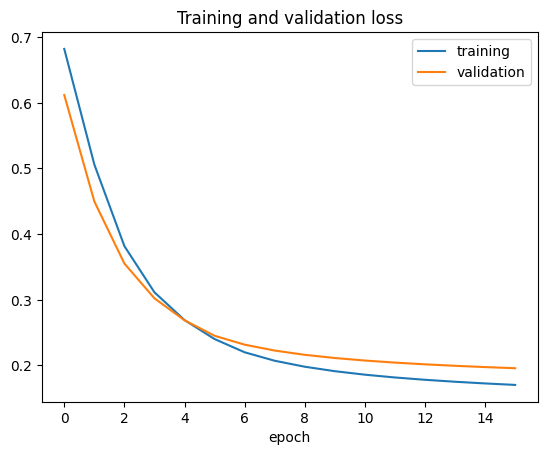

<Figure size 640x480 with 0 Axes>

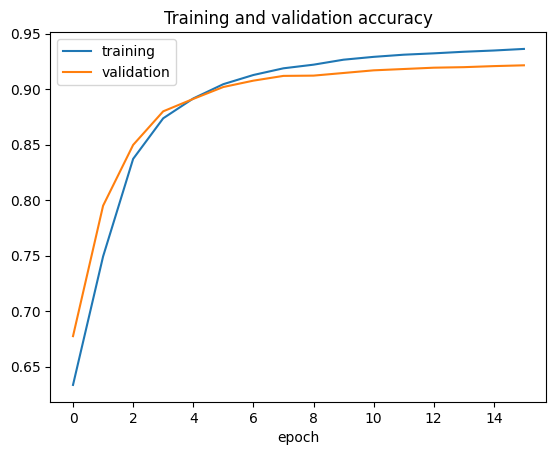

------------------------------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [17]:
model_summary(model, history)

## **Evaluation on test set**

In [18]:
# evaluate the network
print("Evaluating network...")
predictions = model.predict(X_test_nn)
preds = predictions > 0.5

Evaluating network...
132/132 ━━━━━━━━━━━━━━━━━━━━ 46s 329ms/step


> Correct Predictions: 3895
> Wrong Predictions: 299


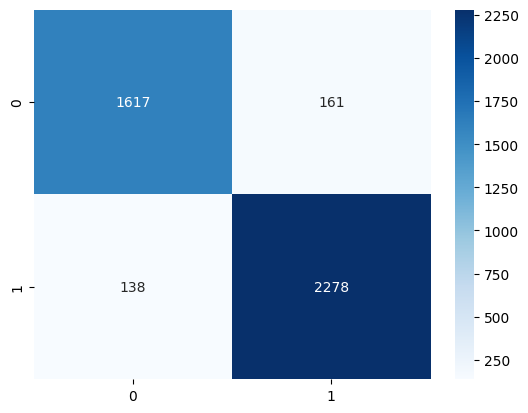

              precision    recall  f1-score   support

 NonViolence       0.92      0.91      0.92      1778
    Violence       0.93      0.94      0.94      2416

    accuracy                           0.93      4194
   macro avg       0.93      0.93      0.93      4194
weighted avg       0.93      0.93      0.93      4194



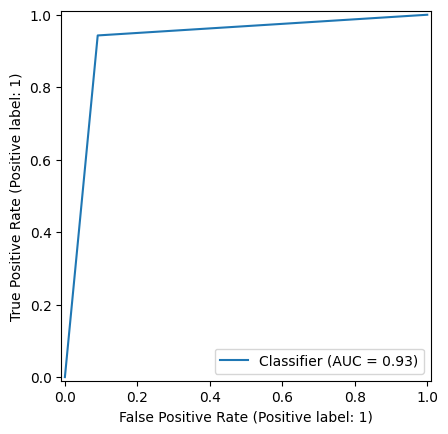

In [20]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix
)

corr_pred = confusion_matrix(y_test, preds)

n_correct = int(corr_pred[0][0] + corr_pred[1][1])
print('> Correct Predictions:', n_correct)

n_wrongs = int(corr_pred[0][1] + corr_pred[1][0])
print('> Wrong Predictions:', n_wrongs)

sns.heatmap(corr_pred, annot=True, fmt="d", cmap="Blues")
plt.show()

print(classification_report(y_test, preds,
                           target_names=["NonViolence", "Violence"]))

# ROC Curve plot
RocCurveDisplay.from_predictions(y_test, preds)
plt.show()


In [21]:

model.save("violence_detection_model.keras")


In [22]:
model.save_weights("modelnew.weights.h5")
